In [1]:
import numpy as np
import pandas as pd

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [3]:
import warnings
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

Read and Check Data


In [4]:
df=pd.read_csv(r"C:\Users\C\Downloads\ncr_ride_bookings.csv")

In [5]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [7]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

Checking missing values for each category

In [10]:
df["Booking Status"].isna().sum()

0

In [11]:
columns_to_check = [
    "Avg VTAT", "Avg CTAT", 
    "Cancelled Rides by Customer", "Reason for cancelling by Customer",
    "Cancelled Rides by Driver", "Driver Cancellation Reason",
    "Incomplete Rides", "Incomplete Rides Reason", "Booking Value",
    "Ride Distance", "Driver Ratings", "Customer Rating", "Payment Method"
]

for status in df["Booking Status"].unique():
    subset = df[df["Booking Status"] == status][columns_to_check]
    total_rows = len(subset)
    null_counts = subset.isna().sum()
    non_null_counts = subset.notna().sum()
    
    print(f"\n=== Booking Status: {status} ===")
    print(f"Total rows: {total_rows}")
    print("\nNull counts per column:")
    print(null_counts)
    print("\nNon-null counts per column:")
    print(non_null_counts)
    print("\nUnique values per column:")
    for col in columns_to_check:
        print(f"{col}: {subset[col].unique()}")


=== Booking Status: No Driver Found ===
Total rows: 10500

Null counts per column:
Avg VTAT                             10500
Avg CTAT                             10500
Cancelled Rides by Customer          10500
Reason for cancelling by Customer    10500
Cancelled Rides by Driver            10500
Driver Cancellation Reason           10500
Incomplete Rides                     10500
Incomplete Rides Reason              10500
Booking Value                        10500
Ride Distance                        10500
Driver Ratings                       10500
Customer Rating                      10500
Payment Method                       10500
dtype: int64

Non-null counts per column:
Avg VTAT                             0
Avg CTAT                             0
Cancelled Rides by Customer          0
Reason for cancelling by Customer    0
Cancelled Rides by Driver            0
Driver Cancellation Reason           0
Incomplete Rides                     0
Incomplete Rides Reason              0
Boo

Expected Optional Fields are correct ; we can fill na safely for flags (One Hot Encoding) now

In [12]:
cols_fill_na_zero = ["Cancelled Rides by Customer", "Cancelled Rides by Driver" , "Incomplete Rides"]
df[cols_fill_na_zero] = df[cols_fill_na_zero].fillna(0)

In [13]:
df[cols_fill_na_zero].head()

,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides
0,0.0,0.0,0.0
1,0.0,0.0,1.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


In [14]:
df[cols_fill_na_zero].isna().sum()

Cancelled Rides by Customer    0
Cancelled Rides by Driver      0
Incomplete Rides               0
dtype: int64

Feature Engineering
Extract Season, Year,Month, Day, Weekday

In [22]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.day_name()

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["Season"] = df["Month"].apply(get_season)
print(df.head())

        Date      Time    Booking ID   Booking Status   Customer ID  \
0 2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1 2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2 2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3 2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4 2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   

    Vehicle Type      Pickup Location      Drop Location  Avg VTAT  Avg CTAT  \
0          eBike          Palam Vihar            Jhilmil       NaN       NaN   
1       Go Sedan        Shastri Nagar  Gurgaon Sector 56       4.9      14.0   
2           Auto              Khandsa      Malviya Nagar      13.4      25.8   
3  Premier Sedan  Central Secretariat           Inderlok      13.1      28.5   
4           Bike     Ghitorni Village        Khan Market       5.3      19.6   

   ...  Booking Value Ride Distance  Driver Ratings Customer Rating  \
0  ...            NaN

Extract Hour from time


In [23]:
df["Hour"] = pd.to_datetime(df["Time"], format="%H:%M:%S").dt.hour
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Year,Month,Day,DayOfWeek,Season,Hour
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,2024,3,23,Saturday,Spring,12
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,5.73,NaN,NaN,UPI,2024,11,29,Friday,Fall,18
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,13.58,4.9,4.9,Debit Card,2024,8,23,Friday,Summer,8
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,34.02,4.6,5.0,UPI,2024,10,21,Monday,Fall,17
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,48.21,4.1,4.3,UPI,2024,9,16,Monday,Fall,22


Create Trio Column for easier Power Bi visualization


In [24]:
df["trip"] = df["Pickup Location"] + " -> " + df["Drop Location"]
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Driver Ratings,Customer Rating,Payment Method,Year,Month,Day,DayOfWeek,Season,Hour,trip
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,2024,3,23,Saturday,Spring,12,Palam Vihar -> Jhilmil
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,UPI,2024,11,29,Friday,Fall,18,Shastri Nagar -> Gurgaon Sector 56
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,4.9,4.9,Debit Card,2024,8,23,Friday,Summer,8,Khandsa -> Malviya Nagar
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,4.6,5.0,UPI,2024,10,21,Monday,Fall,17,Central Secretariat -> Inderlok
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,4.1,4.3,UPI,2024,9,16,Monday,Fall,22,Ghitorni Village -> Khan Market


Answering Questions


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

Investigating Availability

In [29]:
demand_per_hour=df.groupby("Hour")["Booking ID"].count()
demand_stats=demand_per_hour.describe()
print("Demand per hour:\n",demand_per_hour)
print("Demand stats per hour:\n",demand_stats)

Demand per hour:
 Hour
0      1373
1      1360
2      1339
3      1383
4      1321
5      2786
6      4160
7      5450
8      6861
9      8234
10     9577
11     8390
12     7006
13     5470
14     7031
15     8202
16     9633
17    11044
18    12397
19    11047
20     9630
21     8103
22     5441
23     2762
Name: Booking ID, dtype: int64
Demand stats per hour:
 count       24.000000
mean      6250.000000
std       3521.771787
min       1321.000000
25%       2780.000000
50%       6933.500000
75%       8686.750000
max      12397.000000
Name: Booking ID, dtype: float64


No Driver Found Stats per Hour:
 count     24.000000
mean     437.500000
std      245.855914
min       89.000000
25%      184.750000
50%      471.500000
75%      612.500000
max      891.000000
Name: Booking ID, dtype: float64


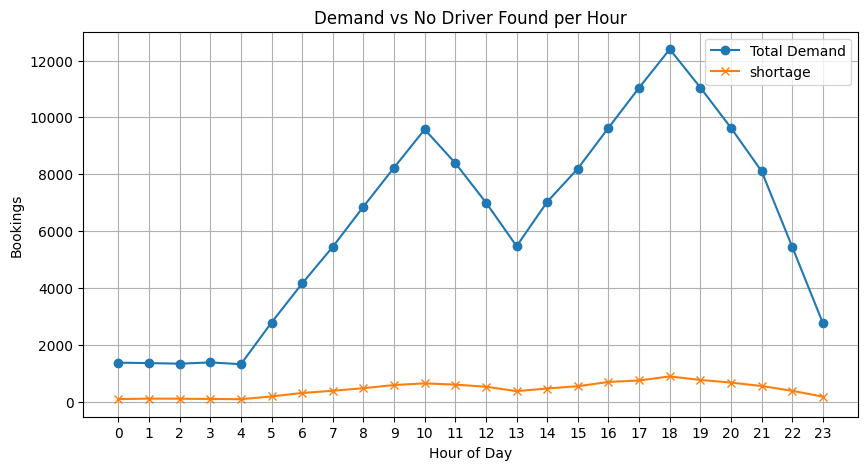

In [33]:
no_driver_per_hour = df[df["Booking Status"] == "No Driver Found"].groupby("Hour")["Booking ID"].count()
no_driver_stats = no_driver_per_hour.describe()
print("No Driver Found Stats per Hour:\n", no_driver_stats)

plt.figure(figsize=(10,5))
plt.plot(demand_per_hour.index,demand_per_hour.values,marker='o',label="Total Demand")
plt.plot(no_driver_per_hour.index,no_driver_per_hour.values,marker='x',label="shortage")
plt.title("Demand vs No Driver Found per Hour")
plt.xlabel ("Hour of Day")
plt.ylabel ("Bookings")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()


In [34]:
comparison = pd.DataFrame({
    "Total Demand": demand_per_hour,
    "No Driver Found": no_driver_per_hour
}).fillna(0)

comparison["No Driver %"] = (comparison["No Driver Found"] / comparison["Total Demand"]) * 100

corr = demand_per_hour.corr(no_driver_per_hour)
print(f"Correlation between Demand and Shortage per Hour: {corr:.4f}")

print(comparison)


Correlation between Demand and Shortage per Hour: 0.9976
      Total Demand  No Driver Found  No Driver %
Hour                                            
0             1373               93     6.773489
1             1360              110     8.088235
2             1339              107     7.991038
3             1383               99     7.158351
4             1321               89     6.737320
5             2786              187     6.712132
6             4160              308     7.403846
7             5450              387     7.100917
8             6861              477     6.952339
9             8234              588     7.141122
10            9577              647     6.755769
11            8390              601     7.163290
12            7006              529     7.550671
13            5470              373     6.819013
14            7031              466     6.627791
15            8202              547     6.669105
16            9633              696     7.225164
17          

           Total Demand  No Driver Found  No Driver %
DayOfWeek                                            
Monday            21644             1469     6.787100
Tuesday           21391             1500     7.012295
Wednesday         21413             1535     7.168542
Thursday          21215             1483     6.990337
Friday            21397             1542     7.206618
Saturday          21542             1485     6.893510
Sunday            21398             1486     6.944574


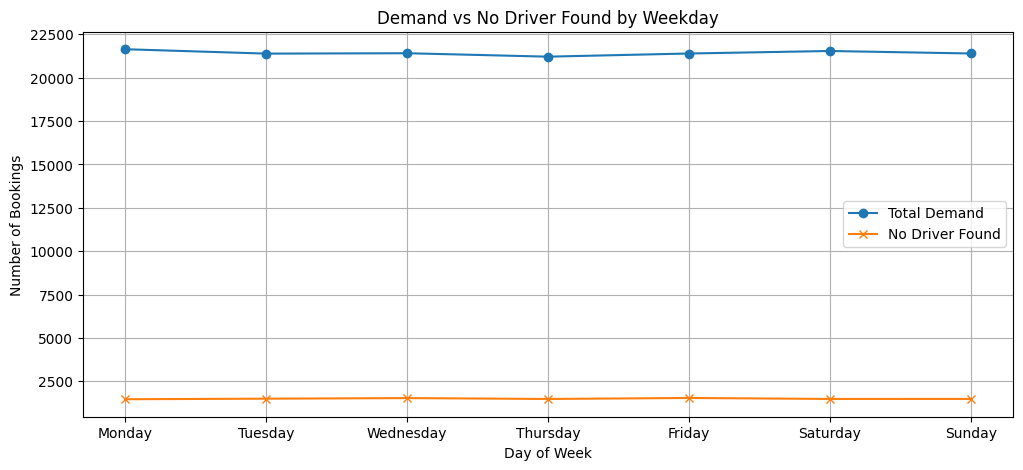

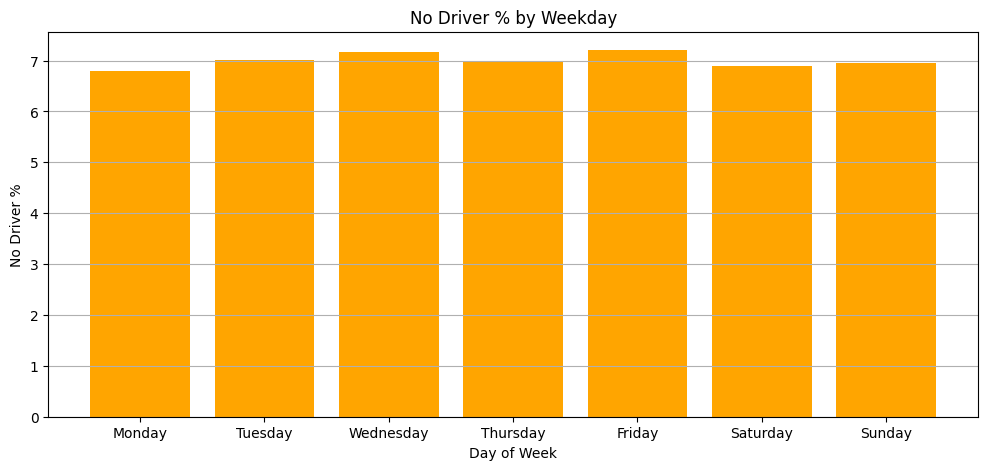

In [42]:
d_demand = df.groupby("DayOfWeek")["Booking ID"].count()

shortage_day = df[df["Booking Status"] == "No Driver Found"].groupby("DayOfWeek")["Booking ID"].count()

weekday_comparison = pd.DataFrame({
    "Total Demand": d_demand,
    "No Driver Found": shortage_day
}).fillna(0)

weekday_comparison["No Driver %"] = (weekday_comparison["No Driver Found"] / weekday_comparison["Total Demand"]) * 100

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_comparison = weekday_comparison.reindex(days_order)

print(weekday_comparison)

plt.figure(figsize=(12,5))
plt.plot(weekday_comparison.index, weekday_comparison["Total Demand"], marker='o', label="Total Demand")
plt.plot(weekday_comparison.index, weekday_comparison["No Driver Found"], marker='x', label="No Driver Found")
plt.title("Demand vs No Driver Found by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Number of Bookings")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.bar(weekday_comparison.index, weekday_comparison["No Driver %"], color="orange")
plt.title("No Driver % by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("No Driver %")
plt.grid(axis="y")
plt.show( )



=== Monthly Comparison ===
       Total Demand  No Driver Found  No Driver %
Month                                            
1             12861              885     6.881269
2             11927              850     7.126687
3             12719              892     7.013130
4             12199              842     6.902205
5             12778              869     6.800751
6             12440              856     6.881029
7             12897              904     7.009382
8             12636              936     7.407407
9             12248              904     7.380797
10            12651              867     6.853213
11            12394              861     6.946910
12            12250              834     6.808163


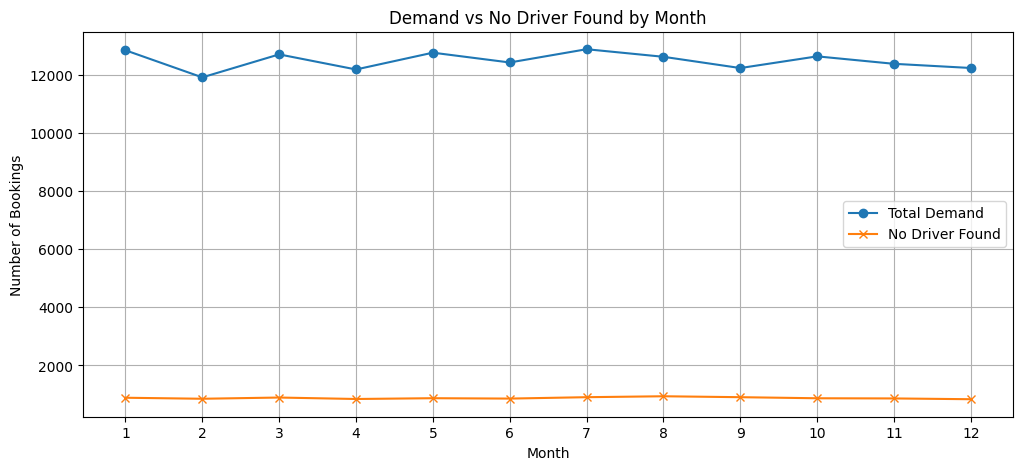

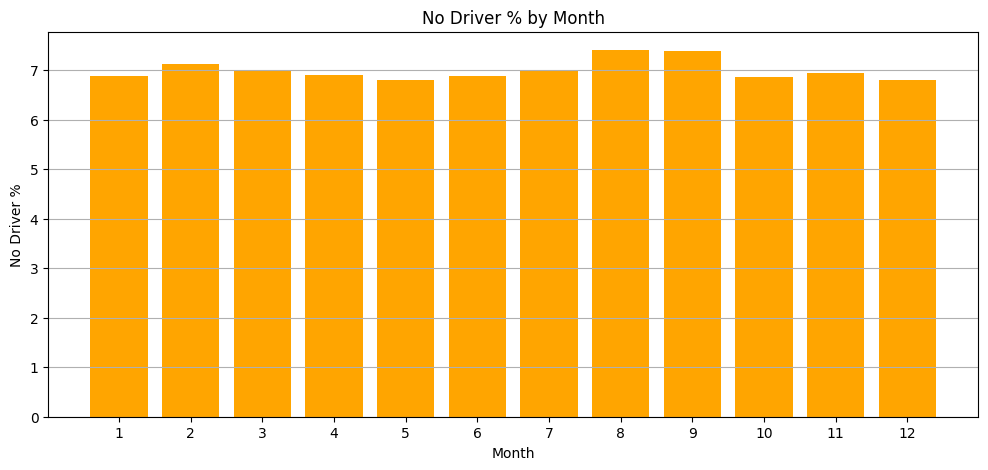

In [50]:
demand_m = df.groupby("Month")["Booking ID"].count()
no_driver_per_month = df[df["Booking Status"] == "No Driver Found"].groupby("Month")["Booking ID"].count()

compare_m = pd.DataFrame({
    "Total Demand": demand_m,
    "No Driver Found": no_driver_per_month
}).fillna(0)

compare_m["No Driver %"] = (compare_m["No Driver Found"] / compare_m["Total Demand"]) * 100

compare_m = compare_m.reindex(range(1,13))

print("\n=== Monthly Comparison ===")
print(compare_m)

plt.figure(figsize=(12,5))
plt.plot(compare_m.index, compare_m["Total Demand"], marker='o', label="Total Demand")
plt.plot(compare_m.index, compare_m["No Driver Found"], marker='x', label="No Driver Found")
plt.title("Demand vs No Driver Found by Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(range(1,13))
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.bar(compare_m.index, compare_m["No Driver %"], color="orange")
plt.title("No Driver % by Month")
plt.xlabel("Month")
plt.ylabel("No Driver %")
plt.xticks(range(1,13))
plt.grid(axis="y")
plt.show()


Insights:
1.Peak demand hours:17:00-19:00(evening commmute window)
2.Supply Shortahe is relatively stable (~7% across all time)
3.The system scales decently with demand and different hours, weekdays and months.
4.Despite theres a corr the system is actually accounting for it

Conclusions 
1.they system is stable during day with avout ~7% shortage across all hours, scaling is great during day
2.Problem is ~7% is a high shortage based on domain and business (Based in India), a meeting or consulting an expert would be best to make sure.

Investigating Availability  1. What are least and most pickup locations? 2.What are the distributions of deman and shoratge based on pickup locations?

In [54]:
pickup_demand = df.groupby("Pickup Location")["Booking ID"].count()
pickup_no_driver = df[df["Booking Status"] == "No Driver Found"].groupby("Pickup Location")["Booking ID"].count()

loc_compare = pd.DataFrame({
    "Total Demand": pickup_demand,
    "No Driver Found": pickup_no_driver
}).fillna(0)

loc_compare["No Driver %"] = (loc_compare["No Driver Found"] / loc_compare["Total Demand"]) * 100

most_pickups = loc_compare["Total Demand"].idxmax()
least_pickups = loc_compare["Total Demand"].idxmin()

print(f"Most pickups: {most_pickups} ({loc_compare['Total Demand'].max()} bookings)")
print(f"Least pickups: {least_pickups} ({loc_compare['Total Demand'].min()} bookings)")

high_shortage = loc_compare.sort_values("No Driver %", ascending=False).head(10)
print("\nTop 10 locations with highest No Driver %:")
print(high_shortage)

low_shortage = loc_compare.sort_values("No Driver %", ascending=True).head(10)
print("\nBottom 10 locations with lowest No Driver %:")
print(low_shortage)

print("\nTotal Demand per Pickup Location:")
print(loc_compare["Total Demand"].describe())

print("\nNo Driver % per Pickup Location:")
print(loc_compare["No Driver %"].describe())

Most pickups: Khandsa (949 bookings)
Least pickups: Ghitorni Village (790 bookings)

Top 10 locations with highest No Driver %:
                 Total Demand  No Driver Found  No Driver %
Pickup Location                                            
Old Gurgaon               807               83    10.285006
Paharganj                 825               79     9.575758
Vinobapuri                823               76     9.234508
Rohini West               835               75     8.982036
Greater Noida             866               77     8.891455
Pataudi Chowk             907               80     8.820287
Arjangarh                 810               70     8.641975
Dwarka Mor                840               72     8.571429
Udyog Bhawan              838               71     8.472554
Pitampura                 851               72     8.460635

Bottom 10 locations with lowest No Driver %:
                  Total Demand  No Driver Found  No Driver %
Pickup Location                              

Insights
1.Most pickups: Khandsa → 949 bookings
2.Least pickups: Ghitorni Village → 790 bookings
3.Even the least busy locations have significant demand (~790 rides/day), showing that all areas require adequate coverage.

Locations with highest driver shortage (No Driver %)¶
1.Top 10 high-shortage locations (~8.5–10.3%): Old Gurgaon, Paharganj, Vinobapuri, Rohini West, Greater Noida, Pataudi Chowk, Arjangarh, Dwarka Mor, Udyog Bhawan, Pitampura
2.Common traits: suburban or peripheral areas.

Locations with lowest driver shortage (No Driver %)
1.Bottom 10 low-shortage locations (~4.66–5.53%): IGI Airport, Shivaji Park, Welcome, Malviya Nagar, Vishwavidyalaya, Rohini East, Sohna Road, Golf Course Road, Moti Nagar, RK Puram
2.Common traits: central city or high-demand hubs.

Conclusion 
1.The difference between the lowest and highest order count based on Pickup Location is moderate (790 , 949).
2.Shortage is moderate in central city or high-demand hubs but is almost double in suburban or peripheral areas like "Old Gurgaon".

Investigating Cancellation


    Pickup Location  Cancelled Rides by Driver  Cancelled Rides by Customer
104     Nehru Place                      190.0                         54.0
151    Shivaji Park                      185.0                         58.0
36        GTB Nagar                      183.0                         59.0
124  Pragati Maidan                      179.0                         69.0
141           Saket                      179.0                         70.0
133  Rajouri Garden                      176.0                         52.0
127    Punjabi Bagh                      176.0                         57.0
0             AIIMS                      176.0                         60.0
172      Vinobapuri                      176.0                         68.0
103          Nawada                      174.0                         53.0


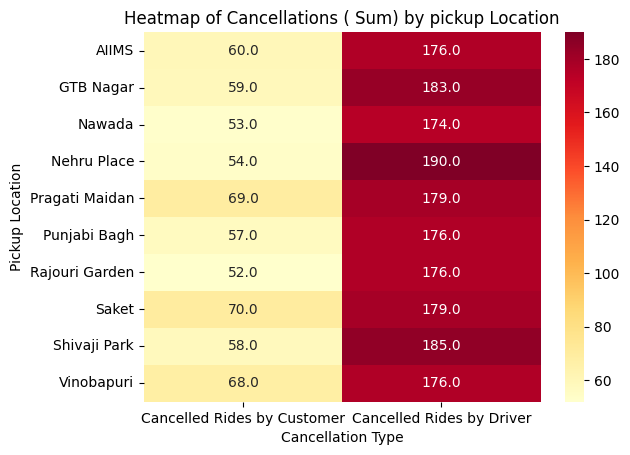

In [55]:
pickup_cancel = (
    df.groupby("Pickup Location")[["Cancelled Rides by Driver", "Cancelled Rides by Customer"]]
      .sum()
      .reset_index()
)

print(pickup_cancel.sort_values("Cancelled Rides by Driver", ascending=False).head(10))
tp = pickup_cancel.sort_values("Cancelled Rides by Driver", ascending=False).head(10)

pickup_matrix=tp.melt(id_vars="Pickup Location",
                      value_vars=["Cancelled Rides by Driver", "Cancelled Rides by Customer"],
    var_name="Type", value_name="Count"
)

pivot=pickup_matrix.pivot(index="Pickup Location",columns="Type",values="Count")

plt.Figure(figsize=(8,5))
sns.heatmap(pivot,annot=True, fmt="",cmap="YlOrRd",cbar=True)
plt.title("Heatmap of Cancellations ( Sum) by pickup Location")
plt.ylabel("Pickup Location")
plt.xlabel("Cancellation Type")
plt.show()

Chart Notes 
1.Most cancellations are made by drivers
2.Peak cancellations happens in " Nehru Place"


   DayOfWeek  Cancelled Rides by Driver  Cancelled Rides by Customer
1     Monday                     4041.0                       1511.0
5    Tuesday                     3919.0                       1469.0
6  Wednesday                     3802.0                       1513.0
4   Thursday                     3752.0                       1479.0
0     Friday                     3777.0                       1566.0
2   Saturday                     3874.0                       1454.0
3     Sunday                     3835.0                       1508.0


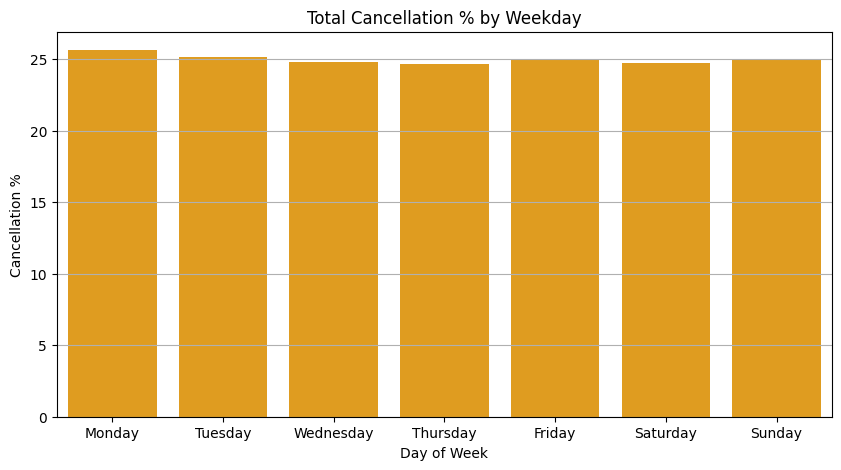

In [56]:
wd_cancel = (
    df.groupby("DayOfWeek")[["Cancelled Rides by Driver", "Cancelled Rides by Customer"]]
      .sum()
      .reset_index()
)

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
wd_cancel["DayOfWeek"] = pd.Categorical(wd_cancel["DayOfWeek"], categories=days_order, ordered=True)
wd_cancel = wd_cancel.sort_values("DayOfWeek")

print(wd_cancel)

wd_cancel["Total Cancelled"] = (
    wd_cancel["Cancelled Rides by Driver"] + wd_cancel["Cancelled Rides by Customer"]
)

d_demand = df.groupby("DayOfWeek")["Booking ID"].count().reindex(days_order)
wd_cancel["Cancelled %"] = (wd_cancel["Total Cancelled"] / d_demand.values) * 100

plt.figure(figsize=(10,5))
sns.barplot(x="DayOfWeek", y="Cancelled %", data=wd_cancel, color="orange")

plt.title("Total Cancellation % by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Cancellation %")
plt.grid(axis="y")
plt.show()


Note: Cancellation is almost same across all days of week

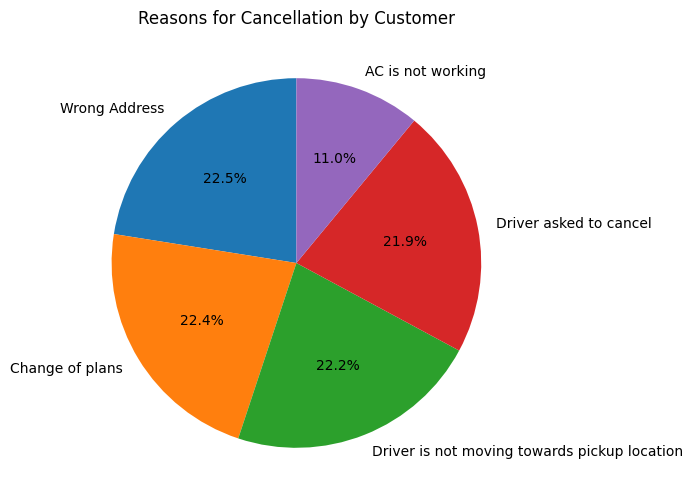

In [ ]:
customer_reasons=(df[df["Booking Status"]=="Cancelled by Customer"]["Reason for cancelling by Customer"]).value_counts(dropna=True)

plt.figure(figsize=(8,6))
plt.pie(customer_reasons, labels=customer_reasons.index, autopct="%1.1f%%", startangle=90)
plt.title("Reasons for Cancellation by Customer")
plt.show()

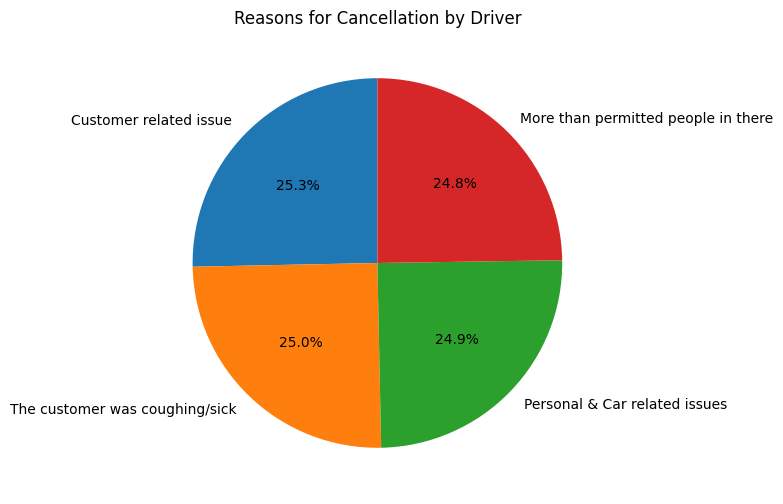

In [62]:
driver_reasons = (
    df[df["Booking Status"] == "Cancelled by Driver"]["Driver Cancellation Reason"]
      .value_counts(dropna=True)
)

plt.figure(figsize=(8,6))
plt.pie(driver_reasons, labels=driver_reasons.index, autopct="%1.1f%%", startangle=90)
plt.title("Reasons for Cancellation by Driver")
plt.show()

Investigating Payment


Payment Method Summary with %:
                Booking ID  Booking Value     Ride %  Revenue %
Payment Method                                                 
UPI                  45909     23345101.0  45.008824  45.027618
Cash                 25367     12895649.0  24.869608  24.872900
Uber Wallet          12276      6200898.0  12.035294  11.960182
Credit Card          10209      5224025.0  10.008824  10.076007
Debit Card            8239      4180510.0   8.077451   8.063294


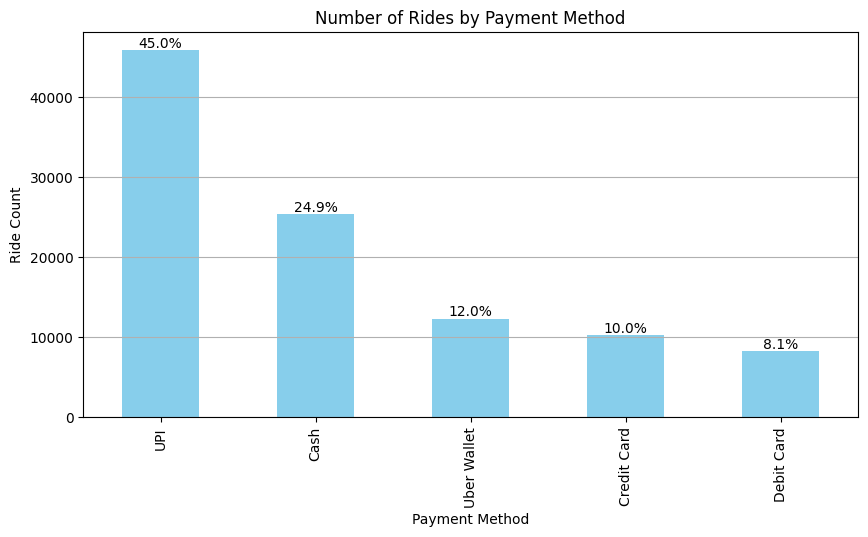

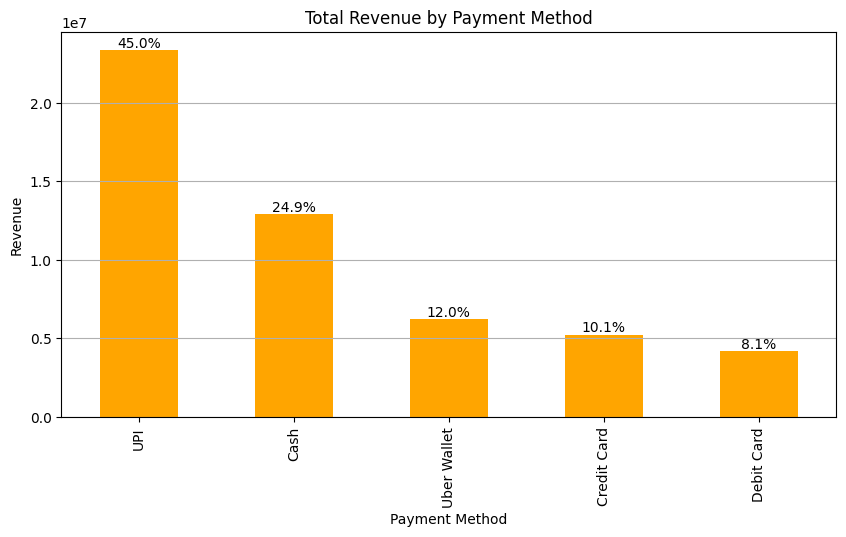

In [64]:
payment_stats = df.groupby("Payment Method").agg({
    "Booking ID": "count",   
    "Booking Value": "sum",      
})

payment_stats["Ride %"] = (payment_stats["Booking ID"] / payment_stats["Booking ID"].sum()) * 100
payment_stats["Revenue %"] = (payment_stats["Booking Value"] / payment_stats["Booking Value"].sum()) * 100

payment_stats = payment_stats.sort_values("Booking Value", ascending=False)

print("Payment Method Summary with %:")
print(payment_stats)

plt.figure(figsize=(10,5))
payment_stats["Booking ID"].plot(kind="bar", color="skyblue")
plt.title("Number of Rides by Payment Method")
plt.ylabel("Ride Count")
plt.xlabel("Payment Method")
for i, val in enumerate(payment_stats["Ride %"]):
    plt.text(i, payment_stats["Booking ID"].iloc[i], f"{val:.1f}%", ha='center', va='bottom')
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(10,5))
payment_stats["Booking Value"].plot(kind="bar", color="orange")
plt.title("Total Revenue by Payment Method")
plt.ylabel("Revenue")
plt.xlabel("Payment Method")
for i, val in enumerate(payment_stats["Revenue %"]):
    plt.text(i, payment_stats["Booking Value"].iloc[i], f"{val:.1f}%", ha='center', va='bottom')
plt.grid(axis="y")
plt.show()



In [65]:
payment_stats["Avg Value per Ride"] = (
    payment_stats["Booking Value"] / payment_stats["Booking ID"]
)
print(payment_stats["Avg Value per Ride"])

Payment Method
UPI            508.508157
Cash           508.363188
Uber Wallet    505.123656
Credit Card    511.707807
Debit Card     507.405025
Name: Avg Value per Ride, dtype: float64


SVC Training+ Hyperparameter tuning + Evaluation


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("ncr_ride_bookings.csv")

# Example: Convert Booking Status into binary (Completed = 1, Cancelled/Other = 0)
df['Booking Status'] = df['Booking Status'].apply(lambda x: 1 if x == 'Completed' else 0)

# Separate features and target
X = df.drop(columns=['Booking Status'])
y = df['Booking Status']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling (Important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning using GridSearch
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svc = SVC()

grid_search = GridSearchCV(
    svc,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

# Best model
best_svc = grid_search.best_estimator_

# Predictions
y_pred = best_svc.predict(X_test_scaled)

# Evaluation
print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

ValueError: could not convert string to float: '2024-04-06'

In [70]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
#

# ===============================
# 3. Target Variable Creation
# ===============================
df["Target"] = df["Booking Status"].apply(
    lambda x: 1 if x == "Completed" else 0
)

# ===============================
# 4. Drop Unnecessary Columns
# ===============================
drop_cols = [
    "Date", "Time", "Booking ID",
    "Customer ID", "trip",
    "Booking Status"
]

df = df.drop(columns=drop_cols)

# ===============================
# 5. Define Features
# ===============================
X = df.drop("Target", axis=1)
y = df["Target"]

# ===============================
# 6. Identify Column Types
# ===============================
categorical_cols = [
    "Vehicle Type", "Pickup Location", 
    "Drop Location", "Payment Method",
    "Season", "DayOfWeek"
]

numerical_cols = [
    "Avg VTAT", "Avg CTAT",
    "Driver Ratings", "Customer Rating",
    "Year", "Month", "Day", "Hour"
]

# ===============================
# 7. Preprocessing Pipelines
# ===============================

from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# ===============================
# 8. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# 9. Build SVC Pipeline
# ===============================
svc_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC())
])

# ===============================
# 10. Hyperparameter Tuning
# ===============================
param_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__kernel": ["linear", "rbf"],
    "classifier__gamma": ["scale", "auto"]
}

grid_search = GridSearchCV(
    svc_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

# ===============================
# 11. Model Evaluation
# ===============================
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ===============================
# 12. Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Ride Completion Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

KeyError: 'Booking Status'